In [6]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import jax.numpy as jnp
from jax import random, jit
from tqdm import tqdm
import re
import os

In [7]:
@jit
def loss(theta,W,data):
    X, y = data
    return jnp.mean((X @ W @ theta - y)**2)

# Sample a dataset of size n
def generate_data(n,m,D_vec,u,kappa,key):
    _, bulk_key, spike_key = random.split(key, 3)
    bulk = random.normal(bulk_key,shape=(n,m))
    spike = u * jnp.ones(shape=(m,)).T * random.normal(spike_key, shape=(n,m))
    X = D_vec * bulk + kappa**(1/2) / jnp.sqrt(m) * spike
    y = X @ u

    return X,y

@jit 
def sgd_update(gamma,theta,W,X,y):
    return theta - gamma * W.T @ X.T @ (X @ W @ theta - y)

# Approximation of risk / test error
@jit
def risk(theta,W,D_vec,u):
    Wtheta = W @ theta
    return jnp.linalg.norm(jnp.sqrt(D_vec) * (Wtheta - u))**2

def train(kappa,m,D_vec,u,theta,gamma,B,r,W,cpts,key):
    num_cpts = np.shape(cpts)[0]
    risks = np.zeros(num_cpts)
    cpt_counter = 0
    for i in tqdm(range(r)):
        key, data_key = random.split(key)
        X, y = generate_data(B,m,D_vec,u,kappa,data_key)
        theta = sgd_update(gamma,theta,W,X,y)
        if (i+1) >= cpts[cpt_counter]:
            risks[cpt_counter] = risk(theta,W,D_vec,u)
            cpt_counter += 1

    return risks

def run_experiment(alpha,beta,kappa,m,d,B,gamma,Cmin,Cmax,mesh_size,n_sims=1):
    D_vec = jnp.power(jnp.arange(m)+1,-2*alpha)
    u = jnp.power(jnp.arange(m)+1,-beta)

    key = random.key(0)

    flops = jnp.logspace(Cmin,Cmax,mesh_size)
    n_flops = jnp.shape(flops)[0]
    risks = np.zeros((n_sims,n_flops))

    gamma = gamma / jnp.sum(jnp.arange(1,m)**(-2.0 * alpha))

    print("Starting experiment: m = {}, d = {}".format(m,d))
    for i in range(n_sims):
        print("Simulation {}...".format(i+1))
        key, W_key = random.split(key)
        W = random.normal(W_key, shape=(m,d)) / jnp.sqrt(d) 
        cpts = flops // (6*B*d)
        r = int(cpts[-1])
        key, data_key = random.split(key)
        theta = jnp.zeros(d)
        risks[i,:] = train(kappa,m,D_vec,u,theta,gamma,B,r,W,cpts,data_key)
    
    risks_mean = np.mean(risks,axis=0)
    risks_std = np.std(risks,axis=0) / np.sqrt(n_sims)
    return risks_mean, risks_std


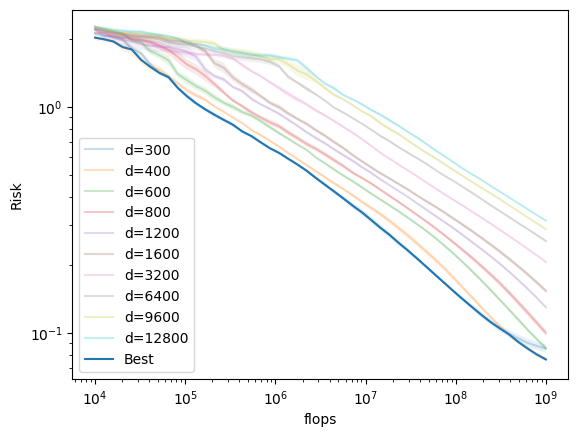

In [11]:
alpha = 0.6
beta = 0.2
kappa = 1.0
gamma = 0.1
B = 1
Cmin = 4
Cmax = 9
mesh_size = 50
num_sims = 4
flops = np.logspace(Cmin,Cmax,mesh_size)

d_list = [300,400,600,800,1200,1600,3200,6400,9600,12800]
num_d = len(d_list)
risks_mean = np.zeros((num_d,mesh_size))
risks_std = np.zeros((num_d,mesh_size))

for (i,d) in enumerate(d_list):
    mean_file = 'results/risks_mean_alpha={},beta={},kappa={},m={},d={},gamma={},B={},Cmin={},Cmax={},mesh_size={},num_sims={}.npy'.format(
        alpha,beta,kappa,2*d,d,gamma,B,Cmin,Cmax,mesh_size,num_sims)
    std_file = 'results/risks_std_alpha={},beta={},kappa={},m={},d={},gamma={},B={},Cmin={},Cmax={},mesh_size={},num_sims={}.npy'.format(
        alpha,beta,kappa,2*d,d,gamma,B,Cmin,Cmax,mesh_size,num_sims)
    mean = np.load(mean_file)
    stderr = np.load(std_file)

    risks_mean[i,:] = mean

    plt.plot(flops,mean,label="d={}".format(d),alpha=0.25)
    plt.fill_between(flops,mean-stderr,mean+stderr,alpha=0.1)
    

best_means = np.min(risks_mean,axis=0)

X = sm.add_constant(np.log(flops))
power_law = sm.OLS(np.log(best_means),X)
res = power_law.fit()
coefs = res.params
yhat = np.exp(coefs[0]) * flops**(coefs[1])

plt.plot(flops,best_means,label="Best")
#plt.plot(flops,yhat,label="Power Law Fit")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("flops")
plt.ylabel("Risk")
plt.savefig("results/scaling_alpha={},beta={},kappa={},gamma={},B={},Cmin={},Cmax={},mesh_size={},num_sims={}.png".format(
    alpha,beta,kappa,gamma,B,Cmin,Cmax,mesh_size,num_sims))

In [12]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 1.425e+04
Date:                Wed, 04 Jun 2025   Prob (F-statistic):           4.79e-61
Time:                        20:38:37   Log-Likelihood:                 71.508
No. Observations:                  50   AIC:                            -139.0
Df Residuals:                      48   BIC:                            -135.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.5606      0.038     94.140      0.000       3.485       3.637
x1            -0.2942      0.002   -119.387      0.000      -0.299      -0.289
==============================================================================
Omnibus:                        3.927   Durbin-Watson:                   0.092
Prob(Omnibus):                  0.140   Jarque-Bera (JB):                1.793
Skew:                           0.004   Prob(JB):                        0.408
Kurtosis:                       2.072   Cond. No.                         69.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""